# 🔬 Breast Cancer Classification — Vision Transformer (ViT) Pipeline
**Dataset:** BUSI (Breast Ultrasound Images)  
**Task:** 3-class classification → benign / malignant / normal  
**Model:** ViT-B/16 pretrained on ImageNet-21k  
**Experiments:** Full Images vs ROI Images + comparison with ResNet baseline

## 0. Install Dependencies

In [ ]:
# Run once
# !pip install torch torchvision timm scikit-learn matplotlib seaborn opencv-python

## 1. Imports & Configuration

In [1]:
import os
import cv2
import copy
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from glob import glob
from functools import partial

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm                          # Provides pretrained ViT models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    precision_recall_fscore_support
)


# ─── Config ──────────────────────────────────────────────────────────────────
class CFG:
    BASE_DIR      = r"C:\ornekler\jupyter\deep_learning\breast-cancer"

    FULL_IMG_DIR  = os.path.join(BASE_DIR, "processed", "classification")
    ROI_IMG_DIR   = os.path.join(BASE_DIR, "processed", "roi")
    SAVE_DIR      = os.path.join(BASE_DIR, "vit_outputs")

    CLASSES       = ["benign", "malignant", "normal"]
    NUM_CLASSES   = 3

    # ViT model name from timm registry
    # Options: 'vit_base_patch16_224', 'vit_small_patch16_224'
    VIT_MODEL     = "vit_base_patch16_224"

    IMAGE_SIZE    = 224              # ViT-B/16 expects exactly 224×224
    PATCH_SIZE    = 16               # 224/16 = 14×14 = 196 patches
    BATCH_SIZE    = 16
    NUM_EPOCHS    = 30
    LR            = 2e-5            # ViT needs smaller LR than CNN
    LR_HEAD       = 1e-3            # Higher LR for the new classification head
    WEIGHT_DECAY  = 1e-2
    WARMUP_EPOCHS = 5               # Linear warmup before cosine decay
    VAL_SPLIT     = 0.15
    TEST_SPLIT    = 0.15
    SEED          = 42
    NUM_WORKERS   = 0               # Keep 0 on Windows/Jupyter
    DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
    LABEL_SMOOTHING = 0.1           # Reduces overconfidence

os.makedirs(CFG.SAVE_DIR, exist_ok=True)
torch.manual_seed(CFG.SEED)
np.random.seed(CFG.SEED)

print(f"Device   : {CFG.DEVICE}")
print(f"Model    : {CFG.VIT_MODEL}")
print(f"Img size : {CFG.IMAGE_SIZE}×{CFG.IMAGE_SIZE}  "
      f"→ {(CFG.IMAGE_SIZE//CFG.PATCH_SIZE)**2} patches")

Device   : cpu
Model    : vit_base_patch16_224
Img size : 224×224  → 196 patches


c:\Users\dellg\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:128: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 1: invalid argument (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10\cuda\CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


## 2. Dataset Class & Data Loading

In [2]:
class BUSIDataset(Dataset):
    """
    Flat class-subfolder dataset.

    root/
      benign/    → label 0
      malignant/ → label 1
      normal/    → label 2
    """

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)    # HWC uint8
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)


# ─── ImageNet statistics ──────────────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]


def make_transforms(image_size, augment=True):
    """
    ViT is sensitive to spatial structure — keep augmentations moderate.
    Strong geometric distortions hurt patch-embedding quality.
    """
    if augment:
        return transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(degrees=15),
            # Light color augmentation — ultrasound is grayscale-ish
            transforms.ColorJitter(brightness=0.15, contrast=0.15),
            transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            transforms.ToTensor(),
            transforms.Normalize(mean=MEAN, std=STD),
        ])
    else:
        return transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=MEAN, std=STD),
        ])


def load_paths_and_labels(root_dir, classes):
    paths, labels = [], []
    for idx, cls in enumerate(classes):
        imgs = sorted(glob(os.path.join(root_dir, cls, "*.png")))
        paths.extend(imgs)
        labels.extend([idx] * len(imgs))
        print(f"  {cls:12s}: {len(imgs):>4} images")
    return paths, labels


def build_splits(paths, labels):
    """Stratified 70/15/15 split."""
    tr_p, te_p, tr_l, te_l = train_test_split(
        paths, labels, test_size=CFG.TEST_SPLIT,
        stratify=labels, random_state=CFG.SEED
    )
    val_ratio = CFG.VAL_SPLIT / (1.0 - CFG.TEST_SPLIT)
    tr_p, va_p, tr_l, va_l = train_test_split(
        tr_p, tr_l, test_size=val_ratio,
        stratify=tr_l, random_state=CFG.SEED
    )
    return (tr_p, tr_l), (va_p, va_l), (te_p, te_l)


def build_dataloaders(root_dir, label=""):
    print(f"\n{'─'*45}")
    print(f"  {label or root_dir}")
    print(f"{'─'*45}")
    paths, labels = load_paths_and_labels(root_dir, CFG.CLASSES)
    (tr_p, tr_l), (va_p, va_l), (te_p, te_l) = build_splits(paths, labels)
    print(f"  Split → Train:{len(tr_p)}  Val:{len(va_p)}  Test:{len(te_p)}")

    tr_ds = BUSIDataset(tr_p, tr_l, make_transforms(CFG.IMAGE_SIZE, augment=True))
    va_ds = BUSIDataset(va_p, va_l, make_transforms(CFG.IMAGE_SIZE, augment=False))
    te_ds = BUSIDataset(te_p, te_l, make_transforms(CFG.IMAGE_SIZE, augment=False))

    kw = dict(batch_size=CFG.BATCH_SIZE, num_workers=CFG.NUM_WORKERS, pin_memory=False)
    return (
        DataLoader(tr_ds, shuffle=True,  **kw),
        DataLoader(va_ds, shuffle=False, **kw),
        DataLoader(te_ds, shuffle=False, **kw),
        te_p, te_l
    )


full_train_dl, full_val_dl, full_test_dl, full_te_paths, full_te_labels = \
    build_dataloaders(CFG.FULL_IMG_DIR, "FULL IMAGES")

roi_train_dl, roi_val_dl, roi_test_dl, roi_te_paths, roi_te_labels = \
    build_dataloaders(CFG.ROI_IMG_DIR, "ROI IMAGES")


─────────────────────────────────────────────
  FULL IMAGES
─────────────────────────────────────────────
  benign      :  437 images
  malignant   :  210 images
  normal      :  133 images
  Split → Train:545  Val:118  Test:117

─────────────────────────────────────────────
  ROI IMAGES
─────────────────────────────────────────────
  benign      :  437 images
  malignant   :  210 images
  normal      :  133 images
  Split → Train:545  Val:118  Test:117


## 3. Model — Pretrained ViT with Custom Head

In [3]:
class ViTClassifier(nn.Module):
    """
    ViT-B/16 backbone (pretrained on ImageNet-21k via timm) with a
    custom classification head for N classes.

    Architecture:
      Patch embedding (16×16 patches)
      → 12 Transformer encoder blocks
      → [CLS] token embedding (dim=768)
      → Dropout → Linear(768→256) → GELU → Dropout → Linear(256→N)
    """

    def __init__(self, model_name, num_classes, pretrained=True, drop_rate=0.3):
        super().__init__()

        # Load backbone — head is replaced so num_classes=0 returns raw features
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,          # Remove original classification head
            drop_rate=drop_rate,
        )

        embed_dim = self.backbone.num_features   # 768 for ViT-B

        # Custom 2-layer classification head
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(p=drop_rate),
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes)
        )

        # Initialize new head weights
        nn.init.xavier_uniform_(self.head[2].weight)
        nn.init.xavier_uniform_(self.head[5].weight)

    def forward(self, x):
        features = self.backbone(x)   # (B, 768) — CLS token output
        return self.head(features)    # (B, num_classes)

    def get_attention_maps(self, x):
        """
        Extract attention weights from the last transformer block
        for attention map visualization.
        Returns: attention tensor shape (B, num_heads, N+1, N+1)
        """
        attn_weights = []

        def hook_fn(module, input, output):
            # timm's Attention module returns (out, attn_weights) when
            # fused_attn is disabled
            attn_weights.append(output)

        # Register hook on the last block's attention module
        last_block = self.backbone.blocks[-1]
        handle = last_block.attn.register_forward_hook(hook_fn)

        with torch.no_grad():
            _ = self.backbone(x)

        handle.remove()
        return attn_weights[0] if attn_weights else None


def build_model():
    return ViTClassifier(
        model_name=CFG.VIT_MODEL,
        num_classes=CFG.NUM_CLASSES,
        pretrained=True
    ).to(CFG.DEVICE)


# Quick sanity check
_m = build_model()
total     = sum(p.numel() for p in _m.parameters())
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"Model      : {CFG.VIT_MODEL}")
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")

# Test forward pass
dummy = torch.randn(2, 3, CFG.IMAGE_SIZE, CFG.IMAGE_SIZE).to(CFG.DEVICE)
out   = _m(dummy)
print(f"Output shape    : {out.shape}   ← (batch, {CFG.NUM_CLASSES} classes)")
del _m, dummy, out

Model      : vit_base_patch16_224
Total params    : 85,997,827
Trainable params: 85,997,827
Output shape    : torch.Size([2, 3])   ← (batch, 3 classes)


## 4. Optimizer — Differential Learning Rates
ViT backbone uses a small LR to preserve pretrained representations.  
The new classification head uses a larger LR to train faster.

In [4]:
def build_optimizer(model):
    """
    Differential learning rates:
      - Backbone (pretrained ViT layers) → small LR
      - New classification head          → larger LR
    """
    backbone_params = list(model.backbone.parameters())
    head_params     = list(model.head.parameters())

    param_groups = [
        {"params": backbone_params, "lr": CFG.LR,      "name": "backbone"},
        {"params": head_params,     "lr": CFG.LR_HEAD,  "name": "head"},
    ]

    return optim.AdamW(param_groups, weight_decay=CFG.WEIGHT_DECAY)


def build_scheduler(optimizer, total_epochs, warmup_epochs):
    """
    Linear warmup → cosine annealing.
    Warmup: LR ramps from 0 to base LR over the first N epochs.
    Then cosine decay to near-zero over the remaining epochs.
    """
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / float(warmup_epochs)
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


print(f"Optimizer  : AdamW (differential LR)")
print(f"  Backbone LR : {CFG.LR}")
print(f"  Head LR     : {CFG.LR_HEAD}")
print(f"Scheduler  : Linear Warmup ({CFG.WARMUP_EPOCHS} epochs) → Cosine Annealing")

Optimizer  : AdamW (differential LR)
  Backbone LR : 2e-05
  Head LR     : 0.001
Scheduler  : Linear Warmup (5 epochs) → Cosine Annealing


## 5. Training & Validation Loop

In [5]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)                  # (B, C)
        loss   = criterion(logits, labels)
        loss.backward()

        # Gradient clipping — important for ViT stability
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


def train_model(train_dl, val_dl, save_name, num_epochs=CFG.NUM_EPOCHS):
    model     = build_model()
    criterion = nn.CrossEntropyLoss(label_smoothing=CFG.LABEL_SMOOTHING)
    optimizer = build_optimizer(model)
    scheduler = build_scheduler(optimizer, num_epochs, CFG.WARMUP_EPOCHS)

    best_acc   = 0.0
    best_state = None
    save_path  = os.path.join(CFG.SAVE_DIR, f"{save_name}.pth")

    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  [],
               "lr":         []}

    print(f"\n{'═'*70}")
    print(f"  Training: {save_name}")
    print(f"{'═'*70}")
    print(f"{'Epoch':>6} | {'T-Loss':>8} | {'T-Acc':>7} | "
          f"{'V-Loss':>8} | {'V-Acc':>7} | {'LR(head)':>10} |")
    print(f"{'─'*70}")

    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_dl, criterion, optimizer, CFG.DEVICE)
        v_loss, v_acc = validate(model, val_dl, criterion, CFG.DEVICE)
        current_lr    = optimizer.param_groups[1]["lr"]   # head LR
        scheduler.step()

        history["train_loss"].append(t_loss); history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc);   history["val_acc"].append(v_acc)
        history["lr"].append(current_lr)

        flag = ""
        if v_acc > best_acc:
            best_acc   = v_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, save_path)
            flag = " ✅"

        print(f"{epoch:>6} | {t_loss:>8.4f} | {t_acc:>6.2%} | "
              f"{v_loss:>8.4f} | {v_acc:>6.2%} | {current_lr:>10.2e} |{flag}")

    print(f"\n  Best Val Acc: {best_acc:.4%}  →  {save_path}")
    model.load_state_dict(best_state)
    return model, history

## 6. Experiment A — ViT on Full Images

In [9]:
full_model, full_history = train_model(
    full_train_dl, full_val_dl,
    save_name="vit_full_images"
)


══════════════════════════════════════════════════════════════════════
  Training: vit_full_images
══════════════════════════════════════════════════════════════════════
 Epoch |   T-Loss |   T-Acc |   V-Loss |   V-Acc |   LR(head) |
──────────────────────────────────────────────────────────────────────
     1 |   1.1893 | 51.38% |   1.1070 | 58.47% |   2.00e-04 | ✅
     2 |   0.9164 | 64.40% |   0.9505 | 67.80% |   4.00e-04 | ✅
     3 |   0.8681 | 69.17% |   0.6731 | 81.36% |   6.00e-04 | ✅
     4 |   0.7993 | 73.94% |   0.7141 | 73.73% |   8.00e-04 |
     5 |   0.7504 | 74.50% |   0.5890 | 84.75% |   1.00e-03 | ✅
     6 |   0.7110 | 79.08% |   0.6693 | 77.97% |   1.00e-03 |
     7 |   0.6413 | 80.92% |   0.6240 | 83.90% |   9.96e-04 |
     8 |   0.5651 | 86.42% |   0.5204 | 86.44% |   9.84e-04 | ✅
     9 |   0.5472 | 87.71% |   0.5951 | 81.36% |   9.65e-04 |
    10 |   0.4817 | 92.29% |   0.5385 | 90.68% |   9.38e-04 | ✅
    11 |   0.4880 | 90.09% |   0.6434 | 85.59% |   9.05e-04 |


## 7. Experiment B — ViT on ROI Images

In [6]:
# Eğer CFG sınıfın varsa:
CFG.BATCH_SIZE = 4  # Örneğin 8 ise 4'e veya 2'ye düşür



In [7]:
roi_model, roi_history = train_model(
    roi_train_dl, roi_val_dl,
    save_name="vit_roi_images"
)


══════════════════════════════════════════════════════════════════════
  Training: vit_roi_images
══════════════════════════════════════════════════════════════════════
 Epoch |   T-Loss |   T-Acc |   V-Loss |   V-Acc |   LR(head) |
──────────────────────────────────────────────────────────────────────
     1 |   0.9744 | 63.12% |   0.6795 | 79.66% |   2.00e-04 | ✅
     2 |   0.8085 | 73.76% |   0.7060 | 82.20% |   4.00e-04 | ✅
     3 |   0.7846 | 74.86% |   0.6414 | 82.20% |   6.00e-04 |
     4 |   0.7384 | 77.98% |   0.6531 | 83.05% |   8.00e-04 | ✅
     5 |   0.7475 | 78.17% |   0.6657 | 85.59% |   1.00e-03 | ✅
     6 |   0.6934 | 79.63% |   0.6614 | 83.90% |   1.00e-03 |
     7 |   0.6636 | 80.73% |   0.5845 | 83.90% |   9.96e-04 |
     8 |   0.6426 | 83.12% |   0.5837 | 87.29% |   9.84e-04 | ✅
     9 |   0.6094 | 84.40% |   0.6281 | 83.05% |   9.65e-04 |
    10 |   0.5902 | 83.30% |   0.6340 | 86.44% |   9.38e-04 |
    11 |   0.5970 | 85.87% |   0.6861 | 86.44% |   9.05e-04 |
   

## 8. Training Curves

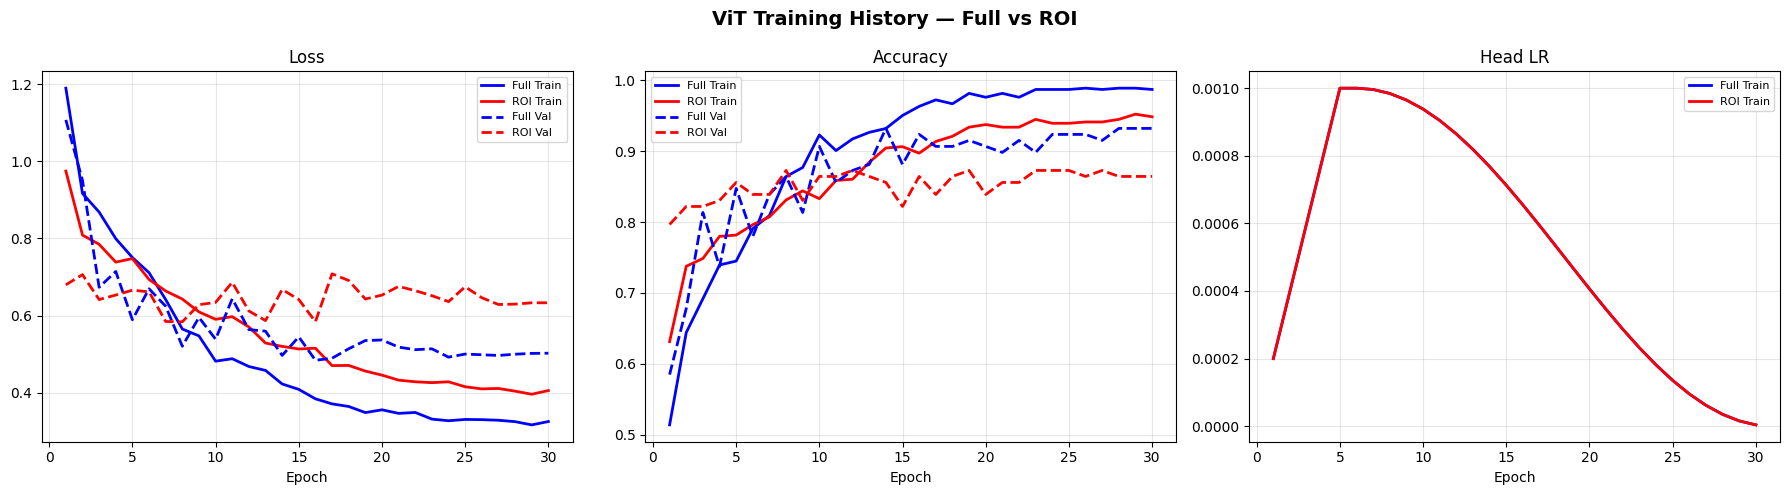

In [10]:
def plot_training_history(hist_full, hist_roi):
    epochs = range(1, len(hist_full["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("ViT Training History — Full vs ROI",
                 fontsize=14, fontweight="bold")

    configs = [
        ("Loss",      "train_loss", "val_loss"),
        ("Accuracy",  "train_acc",  "val_acc"),
        ("Head LR",   "lr",         None),
    ]

    for ax, (title, train_k, val_k) in zip(axes, configs):
        ax.plot(epochs, hist_full[train_k], "b-",  lw=2, label="Full Train")
        ax.plot(epochs, hist_roi[train_k],  "r-",  lw=2, label="ROI Train")
        if val_k:
            ax.plot(epochs, hist_full[val_k], "b--", lw=2, label="Full Val")
            ax.plot(epochs, hist_roi[val_k],  "r--", lw=2, label="ROI Val")
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Epoch")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(CFG.SAVE_DIR, "vit_training_curves.png"), dpi=120)
    plt.show()


plot_training_history(full_history, roi_history)

## 9. Evaluation — Test Set

In [11]:
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    for images, labels in loader:
        images  = images.to(device)
        logits  = model(images)
        probs   = torch.softmax(logits, dim=1).cpu().numpy()
        preds   = logits.argmax(dim=1).cpu().numpy()

        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def evaluate(model, test_dl, name):
    y_true, y_pred, y_prob = get_predictions(model, test_dl, CFG.DEVICE)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")

    print(f"\n{'═'*55}")
    print(f"  {name} — Test Results")
    print(f"{'═'*55}")
    print(f"  Accuracy : {acc:.4%}")
    print(f"  F1 (wtd) : {f1:.4f}")
    print()
    print(classification_report(
        y_true, y_pred,
        target_names=CFG.CLASSES, digits=4
    ))
    return {"y_true": y_true, "y_pred": y_pred,
            "y_prob": y_prob, "acc": acc, "f1": f1, "name": name}


full_res = evaluate(full_model, full_test_dl, "ViT — Full Images")
roi_res  = evaluate(roi_model,  roi_test_dl,  "ViT — ROI Images")


═══════════════════════════════════════════════════════
  ViT — Full Images — Test Results
═══════════════════════════════════════════════════════
  Accuracy : 92.3077%
  F1 (wtd) : 0.9252

              precision    recall  f1-score   support

      benign     0.9531    0.9242    0.9385        66
   malignant     1.0000    0.9032    0.9492        31
      normal     0.7600    0.9500    0.8444        20

    accuracy                         0.9231       117
   macro avg     0.9044    0.9258    0.9107       117
weighted avg     0.9325    0.9231    0.9252       117


═══════════════════════════════════════════════════════
  ViT — ROI Images — Test Results
═══════════════════════════════════════════════════════
  Accuracy : 85.4701%
  F1 (wtd) : 0.8533

              precision    recall  f1-score   support

      benign     0.8824    0.9091    0.8955        66
   malignant     0.7586    0.7097    0.7333        31
      normal     0.9000    0.9000    0.9000        20

    accuracy        

## 10. Confusion Matrices

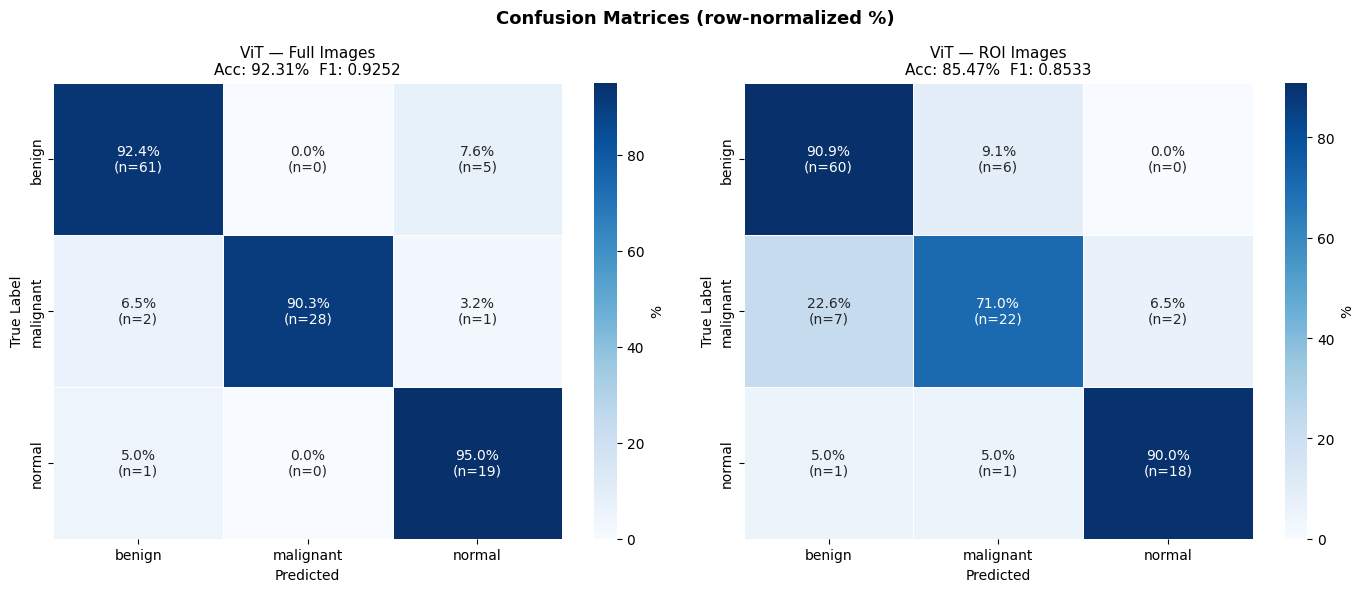

In [12]:
def plot_confusion_matrices(res_list, classes):
    n   = len(res_list)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))
    if n == 1:
        axes = [axes]
    fig.suptitle("Confusion Matrices (row-normalized %)",
                 fontsize=13, fontweight="bold")

    for ax, res in zip(axes, res_list):
        cm     = confusion_matrix(res["y_true"], res["y_pred"])
        cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

        # Annotation: show count AND %
        annot = np.array(
            [[f"{cm_pct[r,c]:.1f}%\n(n={cm[r,c]})"
              for c in range(len(classes))]
             for r in range(len(classes))]
        )

        sns.heatmap(
            cm_pct, annot=annot, fmt="", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            ax=ax, linewidths=0.5, cbar_kws={"label": "%"}
        )
        ax.set_title(
            f"{res['name']}\nAcc: {res['acc']:.2%}  F1: {res['f1']:.4f}",
            fontsize=11
        )
        ax.set_xlabel("Predicted", fontsize=10)
        ax.set_ylabel("True Label", fontsize=10)

    plt.tight_layout()
    plt.savefig(os.path.join(CFG.SAVE_DIR, "confusion_matrices.png"), dpi=120)
    plt.show()


plot_confusion_matrices([full_res, roi_res], CFG.CLASSES)

## 11. Per-Class Metric Bar Chart

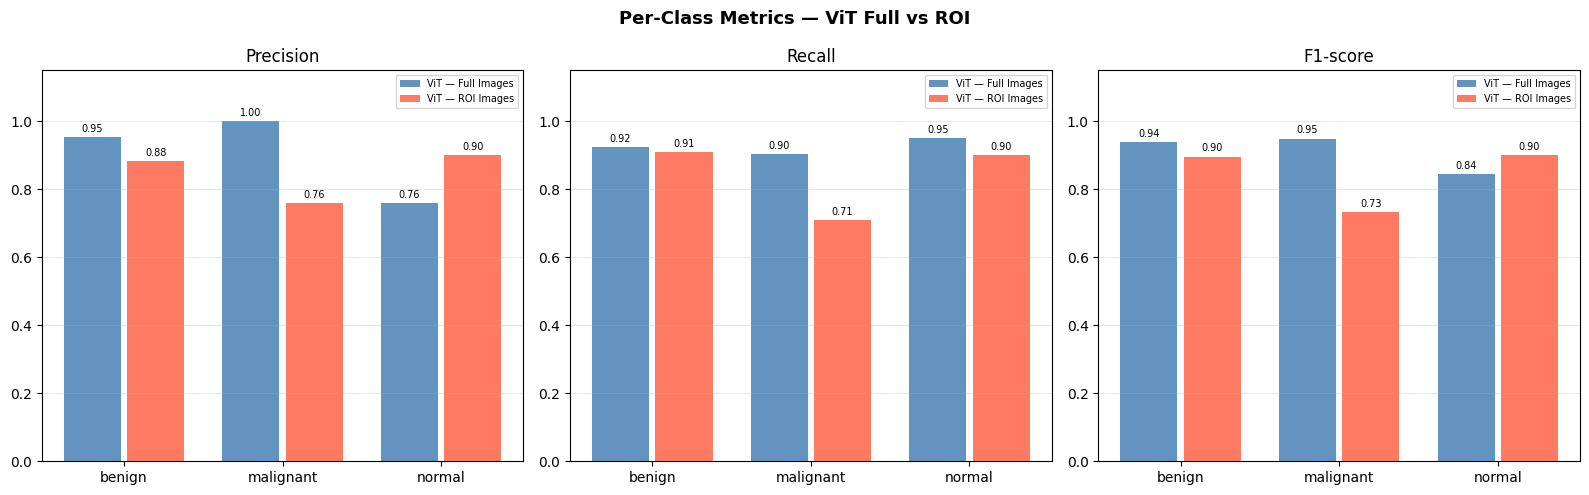

In [13]:
def plot_per_class_metrics(res_list, classes):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Per-Class Metrics — ViT Full vs ROI",
                 fontsize=13, fontweight="bold")

    colors = ["steelblue", "tomato", "mediumseagreen", "goldenrod"]
    x      = np.arange(len(classes))
    width  = 0.8 / len(res_list)

    for ax, metric_name in zip(axes, ["precision", "recall", "f1-score"]):
        for i, res in enumerate(res_list):
            p, r, f, _ = precision_recall_fscore_support(
                res["y_true"], res["y_pred"],
                average=None, labels=[0, 1, 2]
            )
            vals = {"precision": p, "recall": r, "f1-score": f}[metric_name]
            offset = (i - len(res_list) / 2 + 0.5) * width
            bars = ax.bar(x + offset, vals, width=width * 0.9,
                          label=res["name"], color=colors[i], alpha=0.85)
            # Value labels on bars
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                        f"{v:.2f}", ha="center", va="bottom", fontsize=7)

        ax.set_xticks(x); ax.set_xticklabels(classes)
        ax.set_ylim(0, 1.15); ax.set_title(metric_name.capitalize())
        ax.legend(fontsize=7); ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(CFG.SAVE_DIR, "per_class_metrics.png"), dpi=120)
    plt.show()


plot_per_class_metrics([full_res, roi_res], CFG.CLASSES)

## 12. Prediction Visualization — Correct & Misclassified

C:\Users\dellg\AppData\Local\Temp\ipykernel_16336\2311698277.py:60: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
C:\Users\dellg\AppData\Local\Temp\ipykernel_16336\2311698277.py:60: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
C:\Users\dellg\AppData\Local\Temp\ipykernel_16336\2311698277.py:62: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig(save_path, dpi=120)
C:\Users\dellg\AppData\Local\Temp\ipykernel_16336\2311698277.py:62: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.savefig(save_path, dpi=120)
C:\Users\dellg\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dellg\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarnin

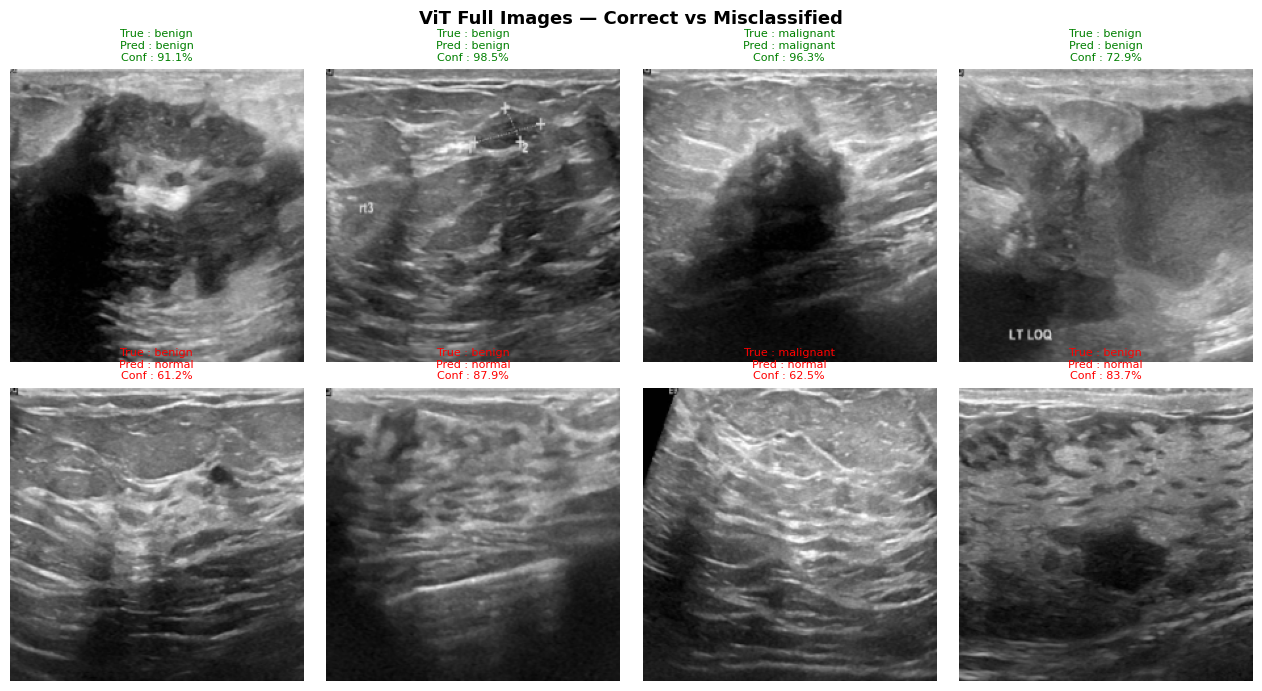

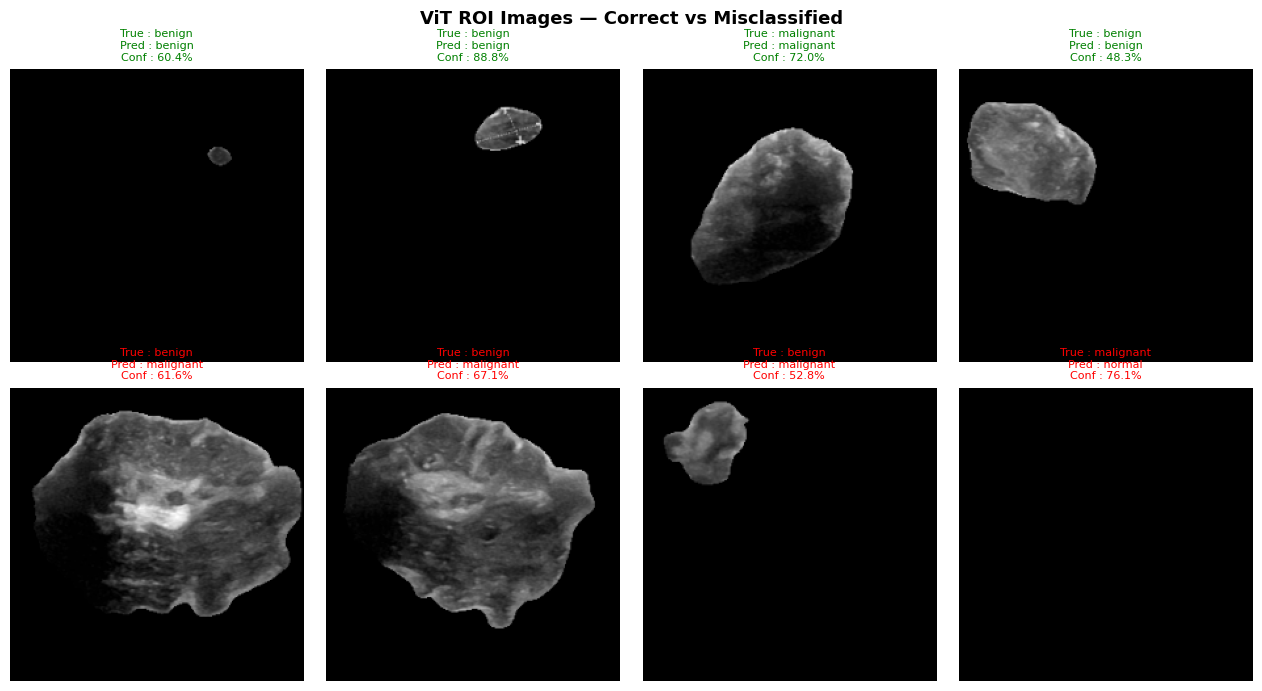

In [14]:
def denormalize(tensor):
    """Reverse ImageNet normalization for display."""
    t = tensor.clone().permute(1, 2, 0).cpu().numpy()
    return np.clip(t * np.array(STD) + np.array(MEAN), 0, 1)


def show_predictions(model, image_paths, true_labels, n_each=4,
                     title="Predictions", save_path=None):
    """
    Grid layout:
      Row 0 — Correctly classified examples
      Row 1 — Misclassified examples
    Each cell shows: image, true label, predicted label, confidence.
    """
    model.eval()
    infer_tf = make_transforms(CFG.IMAGE_SIZE, augment=False)

    correct_samples, wrong_samples = [], []

    for img_path, true_lbl in zip(image_paths, true_labels):
        if len(correct_samples) == n_each and len(wrong_samples) == n_each:
            break

        raw = cv2.imread(img_path)
        raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
        tensor = infer_tf(raw).unsqueeze(0).to(CFG.DEVICE)

        with torch.no_grad():
            out  = model(tensor)
            prob = torch.softmax(out, dim=1).cpu().numpy()[0]
            pred = int(np.argmax(prob))

        entry = (raw, true_lbl, pred, prob)
        if pred == true_lbl and len(correct_samples) < n_each:
            correct_samples.append(entry)
        elif pred != true_lbl and len(wrong_samples) < n_each:
            wrong_samples.append(entry)

    fig, axes = plt.subplots(2, n_each, figsize=(n_each * 3.2, 7))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for row, (samples, row_lbl) in enumerate(
        [(correct_samples, "✅ Correct"), (wrong_samples, "❌ Misclassified")]
    ):
        axes[row][0].set_ylabel(row_lbl, fontsize=11)
        for col in range(n_each):
            ax = axes[row][col]
            if col < len(samples):
                img, true_l, pred_l, prob = samples[col]
                ax.imshow(cv2.resize(img, (CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)))
                color = "green" if pred_l == true_l else "red"
                ax.set_title(
                    f"True : {CFG.CLASSES[true_l]}\n"
                    f"Pred : {CFG.CLASSES[pred_l]}\n"
                    f"Conf : {prob[pred_l]:.1%}",
                    fontsize=8, color=color
                )
            ax.axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120)
    plt.show()


show_predictions(
    full_model, full_te_paths, full_te_labels,
    title="ViT Full Images — Correct vs Misclassified",
    save_path=os.path.join(CFG.SAVE_DIR, "preds_full.png")
)
show_predictions(
    roi_model, roi_te_paths, roi_te_labels,
    title="ViT ROI Images — Correct vs Misclassified",
    save_path=os.path.join(CFG.SAVE_DIR, "preds_roi.png")
)

## 13. Attention Map Visualization
ViT divides the image into 16×16 patches and learns which patches to attend to.  
We visualize the attention from the `[CLS]` token across all 196 spatial patches.

Attention maps — Full Image model


TypeError: get_cls_attention.<locals>.patched_forward() got an unexpected keyword argument 'attn_mask'

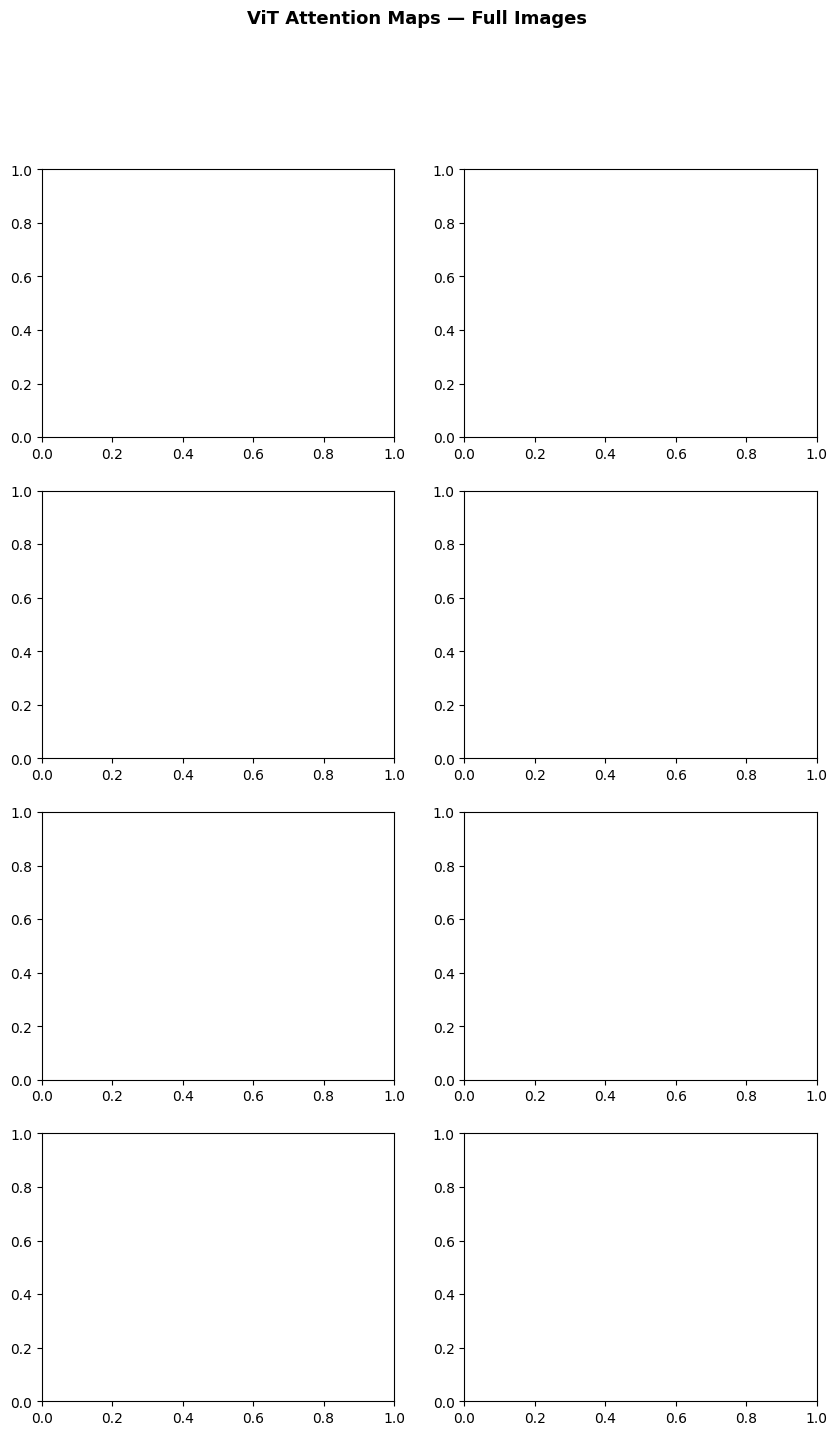

In [23]:
def get_cls_attention(model, img_tensor):
    model.eval()
    last_attn = model.backbone.blocks[-1].attn
    attn_weights_store = []
    original_forward = last_attn.forward   # orijinali sakla

    def patched_forward(x, attn_mask=None, is_causal=False):
        B, N, C = x.shape
        head_dim = C // last_attn.num_heads

        qkv = last_attn.qkv(x).reshape(
            B, N, 3, last_attn.num_heads, head_dim
        ).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        scale = head_dim ** -0.5
        attn  = (q @ k.transpose(-2, -1)) * scale
        attn  = attn.softmax(dim=-1)
        attn_weights_store.append(attn.detach().cpu())

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = last_attn.proj(x)
        x = last_attn.proj_drop(x)
        return x

    last_attn.forward = patched_forward

    try:                                           # ← try/finally garantisi
        with torch.no_grad():
            _ = model.backbone(img_tensor.to(CFG.DEVICE))
    finally:
        last_attn.forward = original_forward       # hata olsa bile geri yükle

    if not attn_weights_store:
        return None

    attn     = attn_weights_store[0][0]            # (num_heads, 197, 197)
    cls_attn = attn[:, 0, 1:]                      # (num_heads, 196)
    grid     = int(math.sqrt(cls_attn.shape[-1]))  # 14
    return cls_attn.reshape(-1, grid, grid).numpy()


def visualize_attention(model, image_paths, true_labels, n_samples=4,
                        title="Attention Maps", save_path=None):
    """
    For each sample: show original image alongside per-head attention maps
    from the last transformer block overlaid as a heatmap.
    """
    infer_tf = make_transforms(CFG.IMAGE_SIZE, augment=False)
    indices  = np.random.choice(len(image_paths), n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, 2, figsize=(10, n_samples * 4))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for row, idx in enumerate(indices):
        img_path  = image_paths[idx]
        true_lbl  = true_labels[idx]

        raw = cv2.imread(img_path)
        raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
        raw_resized = cv2.resize(raw, (CFG.IMAGE_SIZE, CFG.IMAGE_SIZE))

        tensor = infer_tf(raw).unsqueeze(0)

        with torch.no_grad():
            logit = model(tensor.to(CFG.DEVICE))
            pred  = int(logit.argmax(dim=1).cpu())

        cls_attn = get_cls_attention(model, tensor)   # (heads, 14, 14)

        # Average across heads → single map
        attn_mean = cls_attn.mean(axis=0) if cls_attn is not None \
                    else np.ones((14, 14))
        attn_mean = (attn_mean - attn_mean.min()) / \
                    (attn_mean.max() - attn_mean.min() + 1e-8)
        attn_up   = cv2.resize(attn_mean, (CFG.IMAGE_SIZE, CFG.IMAGE_SIZE),
                               interpolation=cv2.INTER_LINEAR)

        # Original image
        ax_img = axes[row][0]
        ax_img.imshow(raw_resized)
        color = "green" if pred == true_lbl else "red"
        ax_img.set_title(
            f"True: {CFG.CLASSES[true_lbl]}  Pred: {CFG.CLASSES[pred]}",
            fontsize=9, color=color
        )
        ax_img.axis("off")

        # Attention overlay
        ax_attn = axes[row][1]
        ax_attn.imshow(raw_resized)
        ax_attn.imshow(attn_up, cmap="jet", alpha=0.5)
        ax_attn.set_title("CLS Attention (avg heads)", fontsize=9)
        ax_attn.axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120)
    plt.show()


print("Attention maps — Full Image model")
visualize_attention(
    full_model, full_te_paths, full_te_labels,
    n_samples=4,
    title="ViT Attention Maps — Full Images",
    save_path=os.path.join(CFG.SAVE_DIR, "attention_full.png")
)

print("Attention maps — ROI model")
visualize_attention(
    roi_model, roi_te_paths, roi_te_labels,
    n_samples=4,
    title="ViT Attention Maps — ROI Images",
    save_path=os.path.join(CFG.SAVE_DIR, "attention_roi.png")
)

## 14. ViT vs ResNet Comparison Table
Fill in ResNet results from your previous classification notebook.

In [ ]:
# ─── Fill in ResNet results from the classification notebook ─────────────────
# Replace 0.0 placeholders with your actual ResNet test scores.
resnet_full_acc = 0.0    # e.g. 0.8412
resnet_full_f1  = 0.9577
resnet_roi_acc  = 0.0
resnet_roi_f1   = 0.8540

rows = [
    ("ResNet50 — Full",  resnet_full_acc, resnet_full_f1),
    ("ResNet50 — ROI",   resnet_roi_acc,  resnet_roi_f1),
    ("ViT-B/16 — Full",  full_res["acc"], full_res["f1"]),
    ("ViT-B/16 — ROI",   roi_res["acc"],  roi_res["f1"]),
]

best_acc = max(r[1] for r in rows)
best_f1  = max(r[2] for r in rows)

print("\n" + "═" * 55)
print(f"  {'Model':<22} {'Accuracy':>12} {'F1 (wtd)':>12}")
print("─" * 55)
for name, acc, f1 in rows:
    acc_flag = " ◀ best" if acc == best_acc else ""
    f1_flag  = " ◀ best" if f1  == best_f1  else ""
    print(f"  {name:<22} {acc:>11.4%}{acc_flag}   {f1:>8.4f}{f1_flag}")
print("═" * 55)

# ─── Bar chart comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("ViT vs ResNet — Full vs ROI", fontsize=13, fontweight="bold")

labels   = [r[0] for r in rows]
accs     = [r[1] for r in rows]
f1s      = [r[2] for r in rows]
bar_clrs = ["steelblue", "cornflowerblue", "tomato", "salmon"]

for ax, vals, metric in zip(axes, [accs, f1s], ["Accuracy", "F1 (weighted)"]):
    bars = ax.bar(labels, vals, color=bar_clrs, alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_title(metric)
    ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CFG.SAVE_DIR, "model_comparison.png"), dpi=120)
plt.show()

NameError: name 'full_res' is not defined

## 15. Final Summary

In [25]:
vit_winner = "ROI Images" if roi_res["f1"] > full_res["f1"] else "Full Images"

print("\n" + "═" * 55)
print("  ViT EXPERIMENT SUMMARY")
print("═" * 55)
print(f"  {'Experiment':<28} {'Accuracy':>10} {'F1':>8}")
print("─" * 55)
print(f"  {'ViT Full Images':<28} {full_res['acc']:>10.4%} {full_res['f1']:>8.4f}")
print(f"  {'ViT ROI Images':<28} {roi_res['acc']:>10.4%} {roi_res['f1']:>8.4f}")
print("═" * 55)
print(f"  Best ViT config: {vit_winner}")
print(f"  Outputs saved → {CFG.SAVE_DIR}")
print("═" * 55)


═══════════════════════════════════════════════════════
  ViT EXPERIMENT SUMMARY
═══════════════════════════════════════════════════════
  Experiment                     Accuracy       F1
───────────────────────────────────────────────────────
  ViT Full Images                92.3077%   0.9252
  ViT ROI Images                 85.4701%   0.8533
═══════════════════════════════════════════════════════
  Best ViT config: Full Images
  Outputs saved → C:\ornekler\jupyter\deep_learning\breast-cancer\vit_outputs
═══════════════════════════════════════════════════════
